# 05 - ML Models and Tuning

This notebook benchmarks multiclass ML models for Bundesliga `1X2` prediction.
It is written as both an analysis notebook and a methodology record for the thesis,
so each major step explains what is being done, why it is done, and what outputs it creates.

## 1. Imports and Setup

We load the shared project helpers for feature filtering, model tuning, rolling backtesting,
feature-set documentation, and run-artifact persistence.

In [15]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR
from src.data_builder import attach_fbref_match_metadata
from src.feature_documentation import build_feature_dictionary, summarize_feature_sets
from src.feature_selection import select_leakage_safe_features, filter_features_by_missingness, filter_features_by_correlation
from src.ml_modeling import get_model_space, score_predictions, build_class_metrics_table, run_static_feature_set_screening
from src.rolling_backtest import run_rolling_backtest, summarize_predictions, evaluate_by_matchday, fit_final_ml_model
from src.run_artifacts import save_run_artifacts, save_deployment_model

## 2. Load the Advanced Match Table and Attach Matchday Metadata

The advanced feature table is the main modeling table.
We also attach FBref matchday metadata because matchday-level diagnostics are useful for evaluating seasonal stability.

In [16]:
features_path = PROCESSED_DATA_DIR / "match_features_advanced.parquet"
if not features_path.exists():
    features_path = PROCESSED_DATA_DIR / "match_features_advanced.csv"

try:
    df = pd.read_parquet(features_path) if features_path.suffix == '.parquet' else pd.read_csv(features_path)
except Exception:
    df = pd.read_csv(PROCESSED_DATA_DIR / 'match_features_advanced.csv')

df['date'] = pd.to_datetime(df['date'], errors='coerce')

fbref_schedule_path = RAW_DATA_DIR / 'fbref' / 'schedule.parquet'
if not fbref_schedule_path.exists():
    fbref_schedule_path = RAW_DATA_DIR / 'fbref' / 'schedule.csv'

try:
    fbref_schedule = pd.read_parquet(fbref_schedule_path) if fbref_schedule_path.suffix == '.parquet' else pd.read_csv(fbref_schedule_path)
except Exception:
    fbref_schedule = pd.read_csv(RAW_DATA_DIR / 'fbref' / 'schedule.csv')
df = df.drop(columns=[col for col in ['round', 'week', 'matchday'] if col in df.columns], errors='ignore').copy()
df = attach_fbref_match_metadata(df, fbref_schedule)

print('Dataset shape:', df.shape)
print(f"FBref matchday merge coverage: {df['matchday'].notna().mean():.1%}")
display(df[['date', 'home_team', 'away_team', 'target_1x2', 'round', 'week', 'matchday']].head())

Dataset shape: (882, 252)
FBref matchday merge coverage: 85.1%


,date,home_team,away_team,target_1x2,round,week,matchday
0,2023-08-18 18:30:00,Werder Bremen,Bayern Munich,A,Bundesliga,1,1
1,2023-08-19 13:30:00,Bayer Leverkusen,RasenBallsport Leipzig,H,Bundesliga,1,1
2,2023-08-19 13:30:00,Wolfsburg,FC Heidenheim,H,Bundesliga,1,1
3,2023-08-19 13:30:00,Hoffenheim,Freiburg,A,Bundesliga,1,1
4,2023-08-19 13:30:00,Augsburg,Borussia M.Gladbach,D,Bundesliga,1,1


## 3. Define the Modeling Objective

The target variable is `target_1x2`, which encodes:
- `H`: home win
- `D`: draw
- `A`: away win

The notebook evaluates models by rolling-origin backtesting on the current season, while tuning hyperparameters on validation windows that use only pre-match information.

In [17]:
TARGET_COL = 'target_1x2'
RUN_KEY = 'ml_multiclass'
TARGET_LABELS = ['H', 'D', 'A']
print(df[TARGET_COL].value_counts(normalize=True).rename('share'))

target_1x2
H    0.420635
A    0.324263
D    0.255102
Name: share, dtype: float64


## 4. Build the Leakage-Safe Candidate Feature Pool

Only clearly pre-match numeric predictors are allowed into the candidate pool.
This prevents direct target leakage and keeps the methodology aligned with a realistic forecasting setup.

In [18]:
candidate_features = select_leakage_safe_features(df)
df_pretest = df[df['season_id'] != 2025].copy()

features_after_missing = filter_features_by_missingness(
    train_df=df_pretest,
    feature_cols=candidate_features,
    max_missing_share=0.35,
)
features_after_corr, dropped_corr_features = filter_features_by_correlation(
    train_df=df_pretest,
    feature_cols=features_after_missing,
    threshold=0.95,
)

print('Candidate features:', len(candidate_features))
print('After missingness filter:', len(features_after_missing))
print('After correlation filter:', len(features_after_corr))
print('Dropped due to correlation:', len(dropped_corr_features))

Candidate features: 219
After missingness filter: 219
After correlation filter: 159
Dropped due to correlation: 60


## 5. Rank the Filtered Features and Define Feature Sets

A lightweight random-forest ranker is used only to create practical feature subsets.
It is not the final predictive model. The goal is to compare several candidate subsets before the more expensive rolling backtest.

In [19]:
X_rank = df_pretest[features_after_corr].copy()
y_rank = df_pretest[TARGET_COL].copy()

rf_selector = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=3,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        )),
    ]
)
rf_selector.fit(X_rank, y_rank)

rf_importance = pd.DataFrame(
    {
        'feature': features_after_corr,
        'importance': rf_selector.named_steps['model'].feature_importances_,
    }
).sort_values('importance', ascending=False).reset_index(drop=True)

top_20_features = rf_importance.head(20)['feature'].tolist()
top_35_features = rf_importance.head(35)['feature'].tolist()
compact_domain_features = [
    col for col in features_after_corr
    if ('elo' in col or 'rest_days' in col or 'expected_points' in col or 'np_xg' in col or 'ppda' in col or 'deep_completions' in col)
]
compact_domain_features = list(dict.fromkeys(compact_domain_features))

feature_sets = {
    'full_filtered': features_after_corr,
    'top_20_rf': top_20_features,
    'top_35_rf': top_35_features,
    'compact_domain': compact_domain_features,
}

display(rf_importance.head(30))

,feature,importance
0,diff_np_xg_for_cum_avg_before,0.017294
1,diff_expected_points_ewm_span_5_venue,0.016631
2,diff_expected_points_cum_avg_before,0.016154
3,diff_deep_completions_cum_avg_before,0.015739
4,diff_expected_points_avg_last_8_venue,0.015186
5,diff_np_xg_for_avg_last_8_venue,0.015053
6,diff_expected_points_avg_last_8_overall,0.014970
7,home_expected_points_cum_avg_before,0.013662
8,home_xg_for_cum_avg_before,0.013630
9,diff_points_cum_avg_before,0.012020


## 6. Document the Feature Subsets

These tables are included to make the methodology easier to describe in the thesis.
The first table summarizes the feature subsets used in the notebook,
while the second table acts as a compact variable dictionary for the included predictors.

In [20]:
feature_set_summary = summarize_feature_sets(feature_sets)
feature_dictionary = build_feature_dictionary(sorted(set().union(*[set(features) for features in feature_sets.values()])))

display(feature_set_summary)
display(feature_dictionary.head(40))

,feature_set,n_features,families_present,family_counts_json,feature_list
0,top_20_rf,20,"Expected goals against, Expected goals for, Ex...","{""Expected goals against"": 2, ""Expected goals ...","diff_np_xg_for_cum_avg_before, diff_expected_p..."
1,top_35_rf,35,"Elo strength, Expected goals against, Expected...","{""Elo strength"": 2, ""Expected goals against"": ...","diff_np_xg_for_cum_avg_before, diff_expected_p..."
2,compact_domain,73,"Elo strength, Expected goal difference, Expect...","{""Elo strength"": 3, ""Expected goal difference""...","home_elo_pre, away_elo_pre, elo_diff_pre, home..."
3,full_filtered,159,"Elo strength, Expected goal difference, Expect...","{""Elo strength"": 3, ""Expected goal difference""...","home_elo_pre, away_elo_pre, elo_diff_pre, home..."


,feature,side,family,scope,horizon,description
0,away_elo_pre,Away team,Elo strength,General pre-match feature,Single-value pre-match feature,Away team; Elo strength; General pre-match fea...
1,elo_diff_pre,Home minus away,Elo strength,Relative difference,Single-value pre-match feature,Home minus away; Elo strength; Relative differ...
2,home_elo_pre,Home team,Elo strength,General pre-match feature,Single-value pre-match feature,Home team; Elo strength; General pre-match fea...
3,diff_np_xg_diff_avg_last_2_overall,Home minus away,Expected goal difference,Relative difference,Short-term form (last 2),Home minus away; Expected goal difference; Rel...
4,diff_np_xg_diff_avg_last_2_venue,Home minus away,Expected goal difference,Relative difference,Short-term form (last 2),Home minus away; Expected goal difference; Rel...
5,away_xg_against_avg_last_2_overall,Away team,Expected goals against,All previous matches,Short-term form (last 2),Away team; Expected goals against; All previou...
6,away_xg_against_avg_last_2_venue,Away team,Expected goals against,Home/away venue split,Short-term form (last 2),Away team; Expected goals against; Home/away v...
7,away_xg_against_avg_last_8_overall,Away team,Expected goals against,All previous matches,Medium-term form (last 8),Away team; Expected goals against; All previou...
8,away_xg_against_avg_last_8_venue,Away team,Expected goals against,Home/away venue split,Medium-term form (last 8),Away team; Expected goals against; Home/away v...
9,away_xg_against_cum_avg_before,Away team,Expected goals against,Season-to-date average,Season-to-date form,Away team; Expected goals against; Season-to-d...


## 7. Define the Model Space and Backtest Configuration

The model space intentionally favors methods that are fast enough to rerun during an active season.
The classical `gradient_boosting` model was removed because it was too slow relative to its practical value in this workflow.

In [ ]:
model_space = get_model_space(random_state=42)
MODEL_RUN_ORDER = list(model_space.keys())
BACKTEST_CONFIG = {
    'test_season_id': 2025,
    'target_col': TARGET_COL,
    'validation_size': 18,
    'min_train_size': 100,
    'n_validation_windows': 4,
    'validation_step_size': 18,
    'primary_metric': 'accuracy',
    'max_missing_share': 0.35,
    'correlation_threshold': 0.95,
    'random_state': 42,
}

print('Models:', MODEL_RUN_ORDER)
BACKTEST_CONFIG

Models: ['logistic_regression', 'naive_bayes', 'knn', 'svm', 'decision_tree', 'random_forest', 'hist_gradient_boosting']


{'test_season_id': 2025,
 'target_col': 'target_1x2',
 'validation_size': 18,
 'min_train_size': 100,
 'n_validation_windows': 4,
 'validation_step_size': 18,
 'primary_metric': 'accuracy',
 'max_missing_share': 0.35,
 'correlation_threshold': 0.95,
 'random_state': 42}

: 

## 8. Run Static Screening and Rolling Backtests

For each model:
- we first compare the predefined feature sets on a cheap static validation split,
- we select the best-performing feature subset,
- we then run a rolling-origin backtest on the 2025 season.

This two-stage workflow keeps the notebook faster while still preserving realistic evaluation.

In [ ]:
model_outputs = {}
screening_tables = []
feature_batch_tables = []

for model_name in MODEL_RUN_ORDER:
    print(f'Running {model_name}...')

    screening = run_static_feature_set_screening(
        df=df,
        feature_sets=feature_sets,
        model_name=model_name,
        model_spec=model_space[model_name],
        target_col=TARGET_COL,
        primary_metric=BACKTEST_CONFIG['primary_metric'],
    )
    best_feature_set = screening.iloc[0]['feature_set']
    selected_features = feature_sets[best_feature_set]

    predictions, tuning, feature_summary = run_rolling_backtest(
        df=df,
        candidate_features=selected_features,
        model_space={model_name: model_space[model_name]},
        **BACKTEST_CONFIG,
    )
    results = summarize_predictions(predictions)

    model_outputs[model_name] = {
        'screening': screening,
        'best_feature_set': best_feature_set,
        'selected_features': selected_features,
        'predictions': predictions,
        'tuning': tuning,
        'feature_summary': feature_summary,
        'results': results,
    }
    screening_tables.append(screening.assign(best_feature_set_selected=screening['feature_set'] == best_feature_set, model=model_name))
    feature_batch_tables.append(feature_summary.assign(model=model_name, feature_set=best_feature_set))

screening_summary = pd.concat(screening_tables, ignore_index=True)
all_predictions = pd.concat([payload['predictions'] for payload in model_outputs.values()], ignore_index=True)
all_tuning = pd.concat([payload['tuning'] for payload in model_outputs.values()], ignore_index=True)
all_feature_batches = pd.concat(feature_batch_tables, ignore_index=True)
all_model_results = pd.concat([payload['results'] for payload in model_outputs.values()], ignore_index=True)
all_model_results = all_model_results.sort_values(['accuracy', 'macro_f1'], ascending=False).reset_index(drop=True)

screening_summary

Running logistic_regression...


## 9. Compare All Model Results

In [ ]:
all_model_results

,model,accuracy,macro_f1,weighted_f1
0,knn,0.514815,0.457888,0.493053
1,naive_bayes,0.477778,0.465611,0.490598
2,random_forest,0.466667,0.427541,0.459966
3,svm,0.455556,0.434346,0.456181
4,hist_gradient_boosting,0.455556,0.380361,0.423430
5,decision_tree,0.448148,0.417460,0.447407
6,logistic_regression,0.440741,0.424608,0.448113


## 10. Validation-vs-Test Diagnostic

This diagnostic highlights an important methodological point: even well-tuned hyperparameters can underperform on the true test season if the validation windows and the future match distribution are not perfectly aligned.

In [ ]:
optimization_diagnostics = (
    all_tuning.groupby('model')
    .agg(
        mean_validation_accuracy=('val_accuracy', 'mean'),
        std_validation_accuracy=('val_accuracy', 'std'),
        mean_validation_macro_f1=('val_macro_f1', 'mean'),
        n_unique_param_sets=('best_params', 'nunique'),
        n_batches=('batch_id', 'nunique'),
    )
    .reset_index()
    .merge(
        all_model_results[['model', 'accuracy', 'macro_f1']].rename(columns={'accuracy': 'test_accuracy', 'macro_f1': 'test_macro_f1'}),
        on='model',
        how='left',
    )
)
optimization_diagnostics['validation_minus_test_accuracy'] = optimization_diagnostics['mean_validation_accuracy'] - optimization_diagnostics['test_accuracy']
optimization_diagnostics.sort_values(['validation_minus_test_accuracy', 'test_accuracy'], ascending=[False, False]).reset_index(drop=True)

,model,mean_validation_accuracy,std_validation_accuracy,mean_validation_macro_f1,n_unique_param_sets,n_batches,test_accuracy,test_macro_f1,validation_minus_test_accuracy
0,random_forest,0.510501,0.046895,0.467573,4,164,0.466667,0.427541,0.043835
1,decision_tree,0.487043,0.052243,0.439969,10,164,0.448148,0.417460,0.038895
2,knn,0.534045,0.050777,0.438013,6,164,0.514815,0.457888,0.019230
3,svm,0.473577,0.047524,0.440191,3,164,0.455556,0.434346,0.018022
4,hist_gradient_boosting,0.468581,0.033277,0.397370,2,164,0.455556,0.380361,0.013025
5,naive_bayes,0.490430,0.036749,0.462878,1,164,0.477778,0.465611,0.012652
6,logistic_regression,0.443936,0.038917,0.409463,3,164,0.440741,0.424608,0.003196


## 11. Accuracy by Bundesliga Matchday

The matchday plot helps assess whether a model is stable over time or whether its predictive accuracy varies sharply across different rounds of the season.

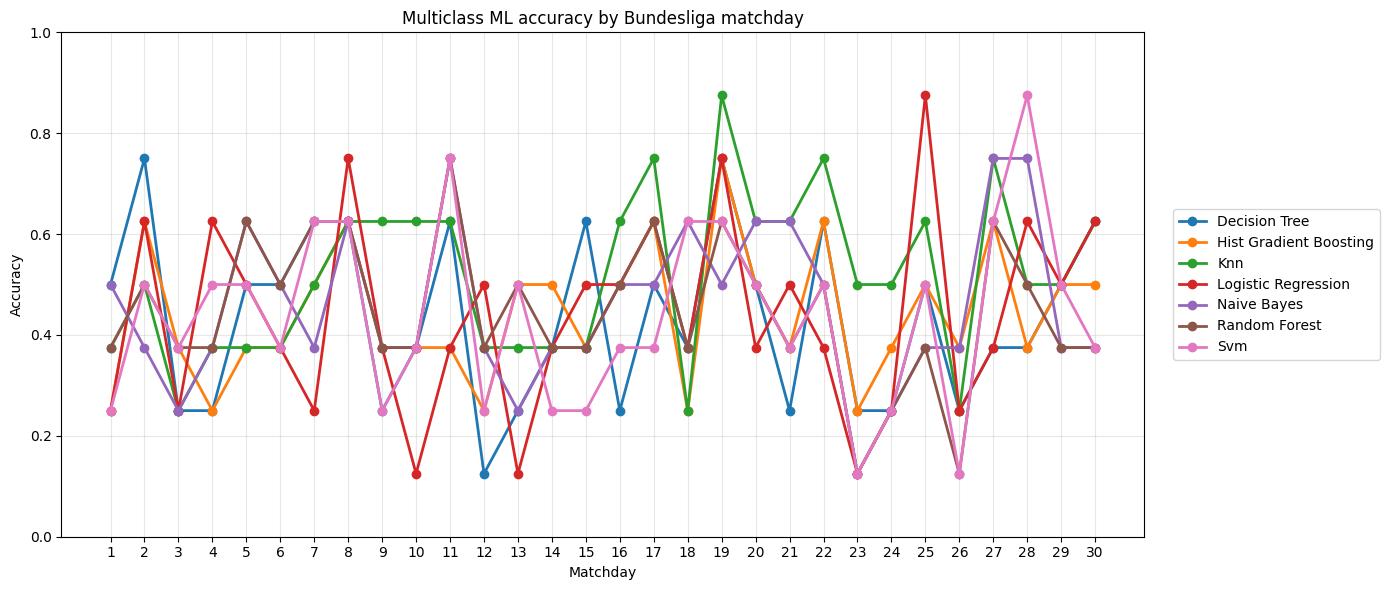

,model,matchday,n_matches,accuracy,macro_f1,weighted_f1
0,decision_tree,1,8,0.500,0.422222,0.383333
1,decision_tree,2,8,0.750,0.571429,0.642857
2,decision_tree,3,8,0.250,0.190476,0.250000
3,decision_tree,4,8,0.250,0.148148,0.222222
4,decision_tree,5,8,0.500,0.500000,0.541667
...,...,...,...,...,...,...
205,svm,26,8,0.125,0.083333,0.093750
206,svm,27,8,0.625,0.523810,0.589286
207,svm,28,8,0.875,0.822222,0.883333
208,svm,29,8,0.500,0.357143,0.473214


In [ ]:
accuracy_by_matchday = evaluate_by_matchday(all_predictions)
fig, ax = plt.subplots(figsize=(14, 6))
for model_name, group in accuracy_by_matchday.groupby('model'):
    ax.plot(group['matchday'], group['accuracy'], marker='o', linewidth=2, label=model_name.replace('_', ' ').title())
ax.set_title('Multiclass ML accuracy by Bundesliga matchday')
ax.set_xlabel('Matchday')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(sorted(accuracy_by_matchday['matchday'].dropna().unique()))
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()
accuracy_by_matchday

## 12. Best-Model Diagnostics

We select the best multiclass ML model and inspect it through class-level metrics, confusion matrices, and the most frequent misclassifications.

In [ ]:
best_model_name = all_model_results.iloc[0]['model']
best_payload = model_outputs[best_model_name]
best_predictions = best_payload['predictions'].copy()
best_tuning = best_payload['tuning'].copy()
best_feature_set = best_payload['best_feature_set']
best_selected_features = best_payload['selected_features']
best_metrics = score_predictions(best_predictions['target'], best_predictions['y_pred'])
best_class_metrics = build_class_metrics_table(best_metrics['classification_report_dict'])

print('Best model:', best_model_name)
print('Best feature set:', best_feature_set)
display(all_model_results[all_model_results['model'] == best_model_name])
display(best_tuning[['val_accuracy', 'val_macro_f1', 'val_weighted_f1']].agg(['mean', 'std', 'min', 'max']).T)
display(best_class_metrics)

Best model: knn
Best feature set: compact_domain


,model,accuracy,macro_f1,weighted_f1
0,knn,0.514815,0.457888,0.493053


,mean,std,min,max
val_accuracy,0.534045,0.050777,0.458333,0.638889
val_macro_f1,0.438013,0.042556,0.358786,0.537007
val_weighted_f1,0.496987,0.041328,0.412047,0.585972


,class,precision,recall,f1_score,support
0,A,0.481481,0.611765,0.538860,85.0
1,D,0.354839,0.166667,0.226804,66.0
2,H,0.580153,0.638655,0.608000,119.0


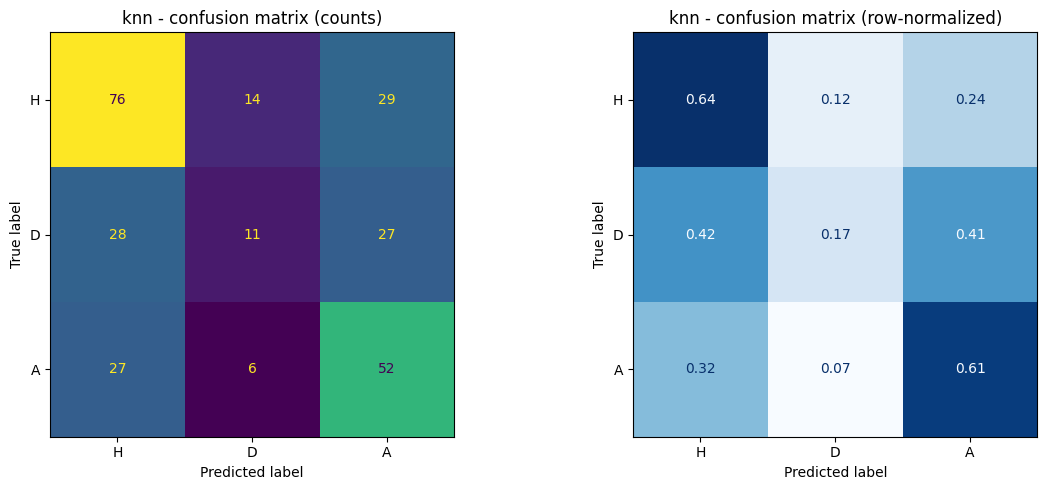

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(best_predictions['target'], best_predictions['y_pred'], labels=TARGET_LABELS), display_labels=TARGET_LABELS).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_model_name} - confusion matrix (counts)')
ConfusionMatrixDisplay(confusion_matrix(best_predictions['target'], best_predictions['y_pred'], labels=TARGET_LABELS, normalize='true'), display_labels=TARGET_LABELS).plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title(f'{best_model_name} - confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

## 13. Save Run Outputs and Persist the Deployment Model

The notebook saves both analysis outputs and one deployment-ready artifact for the best model.
This allows later notebooks to reuse the trained model without repeating the full training loop.

In [ ]:
final_fit = fit_final_ml_model(
    df=df,
    candidate_features=best_selected_features,
    model_name=best_model_name,
    model_spec=model_space[best_model_name],
    target_col=TARGET_COL,
    validation_size=BACKTEST_CONFIG['validation_size'],
    min_train_size=BACKTEST_CONFIG['min_train_size'],
    n_validation_windows=BACKTEST_CONFIG['n_validation_windows'],
    validation_step_size=BACKTEST_CONFIG['validation_step_size'],
    max_missing_share=BACKTEST_CONFIG['max_missing_share'],
    correlation_threshold=BACKTEST_CONFIG['correlation_threshold'],
    primary_metric=BACKTEST_CONFIG['primary_metric'],
)

run_metadata = {
    'run_key': RUN_KEY,
    'target_col': TARGET_COL,
    'task_type': 'multiclass_ml',
    'test_season_id': BACKTEST_CONFIG['test_season_id'],
    'model_order': MODEL_RUN_ORDER,
    'backtest_config': BACKTEST_CONFIG,
    'best_model_name': best_model_name,
    'best_feature_set': best_feature_set,
    'best_selected_features': best_selected_features,
    'deployment_fit_summary': final_fit['fit_summary'],
}

run_dir = save_run_artifacts(
    run_key=RUN_KEY,
    metadata=run_metadata,
    tables={
        'all_model_results': all_model_results,
        'all_predictions': all_predictions,
        'all_tuning': all_tuning,
        'all_feature_batches': all_feature_batches,
        'screening_summary': screening_summary,
        'feature_set_summary': feature_set_summary,
        'feature_dictionary': feature_dictionary,
        'optimization_diagnostics': optimization_diagnostics,
        'accuracy_by_matchday': accuracy_by_matchday,
        'best_model_predictions': best_predictions,
        'best_model_class_metrics': best_class_metrics,
    },
)

artifact_path = save_deployment_model(
    run_key=RUN_KEY,
    artifact_name='best_model',
    model_object={
        'estimator': final_fit['estimator'],
        'selected_features': final_fit['selected_features'],
        'target_col': TARGET_COL,
        'model_name': best_model_name,
        'feature_set_name': best_feature_set,
    },
    metadata={
        'run_key': RUN_KEY,
        'best_model_name': best_model_name,
        'best_feature_set': best_feature_set,
        'selected_features': final_fit['selected_features'],
        'fit_summary': final_fit['fit_summary'],
    },
)

print('Saved run outputs to:', run_dir)
print('Saved deployment artifact to:', artifact_path)

Saved run outputs to: C:\Users\cerve\Desktop\DP\match_prediction\data\processed\model_runs\ml_multiclass
Saved deployment artifact to: C:\Users\cerve\Desktop\DP\match_prediction\outputs\models\deployment\ml_multiclass\best_model.pkl
